In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset

In [3]:
dt = pd.read_csv("/content/drive/MyDrive/IMDB Dataset.csv")

In [4]:
dt.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


#2. Analyze the dataset

In [5]:
# Check for null val
dt.isnull().sum()

,0
review,0
sentiment,0


In [6]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
import re

# Count reviews containing HTML tags
html_pattern = re.compile(r'<.*?>')
html_count = dt['review'].str.contains(html_pattern, regex=True).sum()
print(f"Reviews containing HTML tags: {html_count}")

Reviews containing HTML tags: 29202


In [8]:
# Count reviews containing URLs
url_pattern = re.compile(r'https?://\S+|www\.\S+')
url_count = dt['review'].str.contains(url_pattern, regex=True).sum()
print(f"Reviews containing URLs: {url_count}")

Reviews containing URLs: 195


In [9]:
dt[dt['review'].str.contains(html_pattern, regex=True)].head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
dt[dt['review'].str.contains(url_pattern, regex=True)].head()

,review,sentiment
742,Mario Lewis of the Competitive Enterprise Inst...,negative
907,Following directly from where the story left o...,positive
1088,This quasi J-horror film followed a young woma...,negative
1137,I really think I should make my case and have ...,positive
1141,This show has to be my favorite out of all the...,positive


# 3. Pre-processing on textual dataset

In [11]:
# 1. Convert to Lowercase
dt['review'] = dt['review'].str.lower()

In [12]:
dt.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [13]:
# 2. Remove URLs, HTML Tags, Puntuations

def remove_urls(text):
  text = re.sub(r'http\S+', "", text)           #.sub(Pattern to change, Data to replace, Dataset where gonna perform)
  return text

dt['review'] = dt['review'].apply(remove_urls)  # Apply the fnx and update the dataset

In [14]:
dt.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [15]:
def remove_tags(text):
  text = re.sub(r'<.#?>', "", text)             # <> -> Tag inside, . -> every tag, * -> every char, ? -> until last val

dt['review'] = dt['review'].apply(remove_urls)  # Apply the fnx and update the dataset

In [16]:
dt.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [17]:
# Punctuations = A-Z, a-z, 0-9, \s -> other than all are punct

def remove_punct(text):
  text = re.sub(r'[^A-Za-z0-9\s]', "", text)      #[], exclude all val inside, insert in continuous pattern
  return text

dt['review'] = dt['review'].apply(remove_punct)  # Apply the fnx and update the dataset

In [18]:
dt.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production br br the filmin...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


In [19]:
# 3. Stopwords Removal

import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [20]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

def remove_stopword(text):
  tokens = word_tokenize(text)                     # Tokenize the dataset
  stop_words = stopwords.words('english')          # Initialize the stop-words
# check for stop-words in that TokenSet
  for word in tokens:
    if word in stop_words:
      text = text.replace(word, "")                # remove them and apply on dt
  return text

dt['review'] = dt['review'].apply(remove_stopword)  # Apply the fnx and update the dataset

In [21]:
dt.head()

,review,sentiment
0,e revewers nted wtchg 1 oz epode ll ho...,positive
1,wderful ltle producti br br filming techniqu...,positive
2,thought ths wderful wy spend tme o hot s...,positive
3,bsclly res fmly lttle boy jke thks res zom...,negative
4,petter mtte love time mey vully stunng fi...,positive


In [22]:
# 4. Stemming perform
from nltk.stem import PorterStemmer

def conv_stem(text):
  # Create object
  ps = PorterStemmer()
  # Empty List to store Stemmed words
  stem_words = []

  tokens = word_tokenize(text)      # Tokenize all dataset
  for token in tokens:              # Loop in all tokens
    stem_tokens = ps.stem(token)    # Perform Stemming on tokens
    stem_words.append(stem_tokens)  # Add all stemmed tokens in list

  return " ".join(stem_words)       # covert all stemmed tokens into Strings and add with empty String

dt['review'] = dt['review'].apply(conv_stem)  # Apply the fnx and update the dataset

In [23]:
dt.head()

,review,sentiment
0,e revew nted wtchg 1 oz epod ll hook y rght ex...,positive
1,wder ltle producti br br film techniqu unssum ...,positive
2,thought th wder wy spend tme o hot summer week...,positive
3,bsclli re fmli lttle boy jke thk re zomb close...,negative
4,petter mtte love time mey vulli stunng film wt...,positive


In [24]:
# 5. Label Encoding on Sentiment
from sklearn.preprocessing import LabelEncoder

# Create Object
le = LabelEncoder()

# Train and Update
dt["sentiment"] = le.fit_transform(dt["sentiment"])

In [25]:
dt.head()

,review,sentiment
0,e revew nted wtchg 1 oz epod ll hook y rght ex...,1
1,wder ltle producti br br film techniqu unssum ...,1
2,thought th wder wy spend tme o hot summer week...,1
3,bsclli re fmli lttle boy jke thk re zomb close...,0
4,petter mtte love time mey vulli stunng film wt...,1


In [26]:
y = dt['sentiment']    # Separate Inputs(X) & Output(y)

y.head()

,sentiment
0,1
1,1
2,1
3,0
4,1


In [27]:
# 6. Vectorization by TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer, TfidfTransformer, CountVectorizer

# Create Object
tf_idf = TfidfVectorizer(max_features=10000)      #limit the vocabulary, either it's causes crash

# Train and Update
X = tf_idf.fit_transform(dt['review'])

X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4446622 stored elements and shape (50000, 10000)>

# 4. Split into Train-Test


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
X_train.shape

(40000, 10000)

In [30]:
print(type(X_train))
print(type(y_train))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'pandas.core.series.Series'>


# 5. TensorDataset & DataLoader

In [31]:
# Convert input features from sparse to numpy
X_train = X_train.toarray()
X_test = X_test.toarray()

In [33]:
import torch
from torch.utils.data import TensorDataset, DataLoader

train_dt = TensorDataset(
    torch.from_numpy(X_train).float(),             # Convert into Tensor DataType & Create Tensor Training DataModel
    torch.from_numpy(y_train.values).float()
)

test_dt = TensorDataset(
    torch.from_numpy(X_test).float(),              # Convert into Tensor DataType & Create Tensor Training DataModel
    torch.from_numpy(y_test.values).float()
)

In [34]:
train_dl = DataLoader(train_dt, batch_size=64, shuffle=True)
test_dl = DataLoader(test_dt, batch_size=64, shuffle=True)

# 6. RNN Architecture

In [35]:
import torch.nn as nn
import torch.optim as optim

In [67]:
class RNN(nn.Module):
  def __init__(self, input_size, hidden_size=128, num_layers=1):
    super().__init__()
  # Initializing all constructor parameters
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.num_layers = num_layers

  # Creating RNN layer
  # Default RNN calc. sequence -> (sequence.length, batch_size, input_size)
    self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)    # By batch_first, sequence change
  # Creating Fully Connected Layer(ANN)
    self.fc = nn.Linear(hidden_size, 1)                        # output = 1, so this is a many-to-one architecture

 # Creating Forward Propagation
  def forward(self, x):
  # Calc. Hidden state val, default starting with h0
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

  # Calc. two val --> 1. Hidden State of every timestamp
  #                   2. Final Hidden State of Last Timestamp
    output, _ = self.rnn(x, h0)           # Want 1st val only
  # Take all Batch vals, only last Timestamp val, all Hidden vals
    output = self.fc(output[:, -1, :])
    return output

In [68]:
# Initialize input val
input_size = X.shape[1]
# Call model
model = RNN(input_size)

In [69]:
# Initialize Loss calc. & Optimizer

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 7. Train RNN model

In [70]:
# Default Epochs count
epochs = 15
# Store all losses to plot
train_loss = []

for epoch in range(epochs):
  # Change to training state
  model.train()
  # default total loss
  epoch_loss = 0
  # Loop in Training DataLoader in batch sizes
  for Xb, yb in train_dl:
    # Reset every time Gradient calc.
    optimizer.zero_grad()

    # Increases extra dimension
    Xb = Xb.unsqueeze(1)
    # Forward propagetion
    pred = model.forward(Xb)
    # Decreases dimension for sigmoid application
    output = torch.sigmoid(pred.squeeze())
    # Calc. Loss(Pred vs Actual)
    loss = criterion(output, yb)
    # Back propagation
    loss.backward()
    # Apply Optimizer to update parameters(w)
    optimizer.step()
    # Calc. total loss
    epoch_loss += loss.item()

  # Average loss of the epoch
  avg_epoch_loss = epoch_loss/len(train_dl)
  train_loss.append(avg_epoch_loss)

  print(f"Epoch: {epoch+1}/{epochs} ---> Loss: {avg_epoch_loss}")

Epoch: 1/15 ---> Loss: 0.645549052810669
Epoch: 2/15 ---> Loss: 0.4910393964767456
Epoch: 3/15 ---> Loss: 0.3708566692352295
Epoch: 4/15 ---> Loss: 0.3078727908849716
Epoch: 5/15 ---> Loss: 0.27149369888305663
Epoch: 6/15 ---> Loss: 0.24755864082574844
Epoch: 7/15 ---> Loss: 0.2303152193427086
Epoch: 8/15 ---> Loss: 0.21671542093753815
Epoch: 9/15 ---> Loss: 0.2057132138133049
Epoch: 10/15 ---> Loss: 0.1964609232544899
Epoch: 11/15 ---> Loss: 0.18836722944974899
Epoch: 12/15 ---> Loss: 0.18124526020288467
Epoch: 13/15 ---> Loss: 0.1749454624414444
Epoch: 14/15 ---> Loss: 0.16935422211289405
Epoch: 15/15 ---> Loss: 0.1641457735836506


In [71]:
print(train_loss)

[0.645549052810669, 0.4910393964767456, 0.3708566692352295, 0.3078727908849716, 0.27149369888305663, 0.24755864082574844, 0.2303152193427086, 0.21671542093753815, 0.2057132138133049, 0.1964609232544899, 0.18836722944974899, 0.18124526020288467, 0.1749454624414444, 0.16935422211289405, 0.1641457735836506]


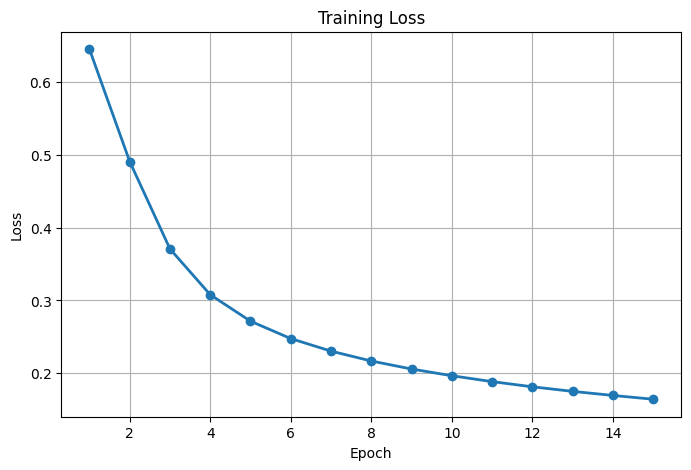

In [72]:
# Plot the Loss val
plt.figure(figsize=(8,5))

plt.plot(range(1, len(train_loss)+1),
         train_loss,
         marker='o',
         linewidth=2)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.savefig("/content/drive/MyDrive/Training Loss")
plt.show()

# 8. Evaluate the model

In [73]:
model.eval()

with torch.no_grad():
  correct = 0.0
  total = 0.0

  for Xb, yb in test_dl:
    Xb = Xb.unsqueeze(1)
    output = model.forward(Xb)
    pred = torch.sigmoid(output.squeeze())
    prediction = (pred > 0.5).float()

    correct += (prediction == yb).sum().item()
    total += yb.size(0)

  print(f"Accuracy Score: {(correct/total)*100}%")

Accuracy Score: 87.58%
